In [50]:
import numpy as np
import torch
import matplotlib.pyplot as plt 
import gpytorch
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import warnings

from funcshape.surface import Surface
from funcshape.testlib.surfaces import HyperbolicParaboloid
from funcshape.visual import plot_surface

In [51]:
def check_scaled_to_unit_interval(arr, tol=1e-2):
    """
    Check whether all values in 'arr' are scaled to [0, 1].
    Raises a warning if not.

    Parameters
    ----------
    arr : array-like
        Input array to check.
    tol : float, optional
        Numerical tolerance to account for floating-point errors.

    Returns
    -------
    bool
        True if array is within [0, 1] (within tolerance), False otherwise.
    """
    arr = np.asarray(arr)

    min_val = np.nanmin(arr)
    max_val = np.nanmax(arr)

    if min_val < -tol or max_val > 1 + tol:
        warnings.warn(
            f"Array values are not within [0, 1]. "
            f"Found min={min_val:.4f}, max={max_val:.4f}.",
            UserWarning
        )
        return False

    return True


class GPRegressionModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.MaternKernel(nu=1.5)
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


class NormalizedGPRegressor:
    def __init__(self, training_iter=200, lr=0.1, device='cpu'):
        self.training_iter = training_iter
        self.lr = lr
        self.device = device

        self.x_scaler = MinMaxScaler()
        self.y_scaler = StandardScaler()

        self.model = None
        self.likelihood = None

    def fit(self, X, y):
        # Ensure numpy arrays
        X = np.asarray(X)
        y = np.asarray(y).reshape(-1, 1)

        # Scale input and target
        X_scaled = self.x_scaler.fit_transform(X)
        y_scaled = self.y_scaler.fit_transform(y).ravel()

        # Convert to torch tensors
        train_x = torch.tensor(X_scaled, dtype=torch.float32).to(self.device)
        train_y = torch.tensor(y_scaled, dtype=torch.float32).to(self.device)

        # Initialize model and likelihood
        self.likelihood = gpytorch.likelihoods.GaussianLikelihood().to(self.device)
        self.model = GPRegressionModel(train_x, train_y, self.likelihood).to(self.device)

        # Find optimal model hyperparameters
        self.model.train()
        self.likelihood.train()

        optimizer = torch.optim.Adam([
            {'params': self.model.parameters()},  # Includes likelihood parameters
        ], lr=self.lr)

        mll = gpytorch.mlls.ExactMarginalLogLikelihood(self.likelihood, self.model)

        for i in range(self.training_iter):
            optimizer.zero_grad()
            output = self.model(train_x)
            loss = -mll(output, train_y)
            loss.backward()
            optimizer.step()

        return self

    def predict(self, X_test, return_std=True):
        X_test = np.asarray(X_test)
        check_scaled_to_unit_interval(X_test)
        test_x = torch.tensor(X_test, dtype=torch.float32).to(self.device)

        self.model.eval()
        self.likelihood.eval()

        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            preds = self.likelihood(self.model(test_x))
            mean = preds.mean.cpu().numpy()
            std = preds.stddev.cpu().numpy()

        # Inverse-transform to original target scale
        mean_original = self.y_scaler.inverse_transform(mean.reshape(-1, 1)).ravel()
        std_original = std * self.y_scaler.scale_[0]

        return (mean_original, std_original) if return_std else mean_original


In [52]:
class PointCloudSurface(Surface):
    def __init__(self, points, uv=None):
        """
        points: (N, 3) array of raw point cloud
        uv: optional (N, 2) parameterization
        """
        self.points = np.asarray(points)

        if uv is None:
            uv = self.points[:,[0,1]]

        # Normalize to [0,1]^2
        # uv = (uv - uv.min(0)) / (uv.max(0) - uv.min(0))
        self.uv = uv

        # Step 2: Fit Gaussian processes for mapping UV -> XYZ
        self.pipeline = NormalizedGPRegressor(training_iter=150, lr=0.05)
        self.pipeline.fit(self.uv, self.points[:, 2])

        # Pass callable mapping into Surface base class
        super().__init__(
            (
                lambda x: x[...,0],
                lambda x: x[...,1],
                lambda x: torch.tensor(self.pipeline.predict(x.detach().cpu().numpy())[0], dtype=torch.float32)
            )
        )

In [53]:
f_analytical = HyperbolicParaboloid()
k = 30
X, Y = torch.meshgrid((torch.linspace(0, 1, k), torch.linspace(0, 1, k)))
X, Y = X.reshape(-1, 1), Y.reshape(-1, 1)
X = torch.cat((X, Y), dim=1)

points = f_analytical(X)

UV shape: (900, 2)


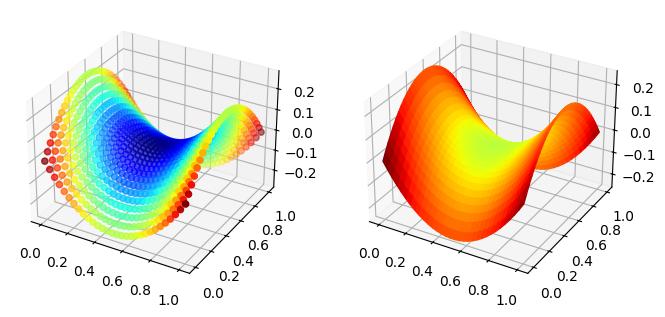

In [54]:
surf = PointCloudSurface(points)
print("UV shape:", surf.uv.shape)  # (N, 2)
curvature = np.asarray([f_analytical.volume_factor(p, h=1e-3).item() for p in points])

fig, axs = plt.subplots(
    1,2,
    figsize=(4*2, 4), 
    subplot_kw = {"projection":"3d"}
)
axs[0].scatter(
    points[:,0],
    points[:,1],
    points[:,2],
    c=curvature,
    cmap="jet"
)
plot_surface(f_analytical, ax=axs[1])
plt.show()

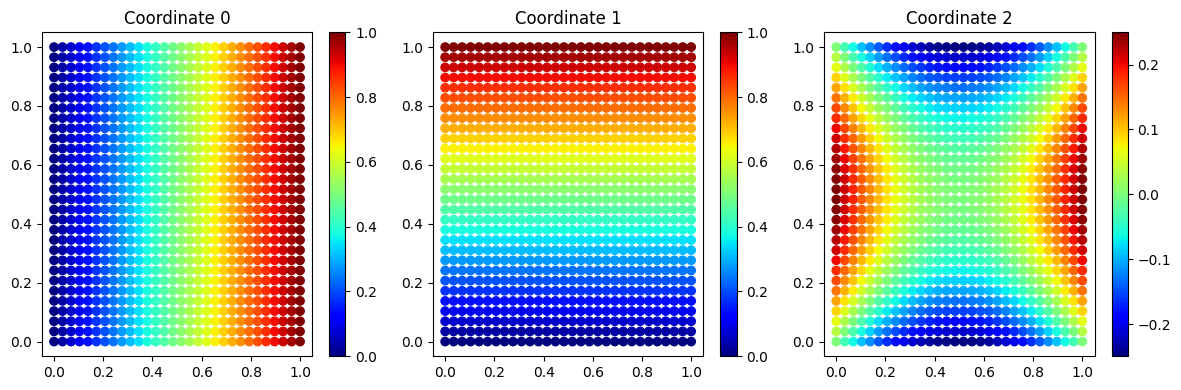

In [55]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
jitter = 1e-2
for i, ax in enumerate(axs):
    emb = surf.uv #+ np.random.normal(scale=jitter, size=surf.uv.shape)
    sc = ax.scatter(
        emb[:, 0], emb[:, 1],
        c=surf.points[:, i],
        cmap="jet"
    )
    fig.colorbar(sc, ax=ax)   # attach a colorbar to this subplot
    ax.set_title(f"Coordinate {i}")

plt.tight_layout()
plt.show()


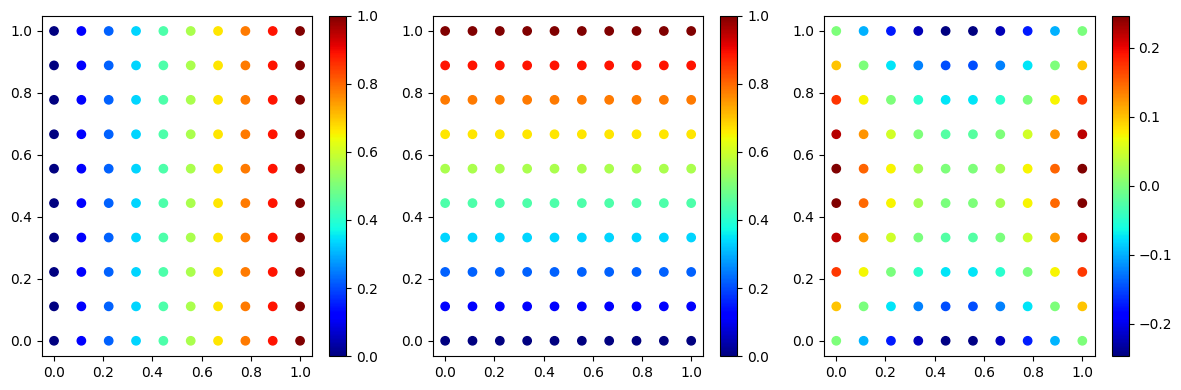

In [56]:
import matplotlib as mpl

n_grid = 10
u = np.linspace(0, 1, n_grid)
v = np.linspace(0, 1, n_grid)
U, V = np.meshgrid(u, v)
uv_grid = np.c_[U.ravel(), V.ravel()]

# Evaluate surface interpolation
pred_points = surf(torch.from_numpy(uv_grid))

fig, axs = plt.subplots(1,3, figsize=(4*3, 4))
for i in range(pred_points.shape[1]):
    cvals = pred_points[:,i]
    norm = mpl.colors.Normalize(vmin=min(cvals), vmax=max(cvals))
    sc = axs[i].scatter(uv_grid[:,0], 
                    uv_grid[:,1], 
                    c = cvals, 
                    cmap="jet",
                    norm = norm
                    )
    fig.colorbar(sc, ax=axs[i])   # attach a colorbar to this subplot

plt.tight_layout()
plt.show()

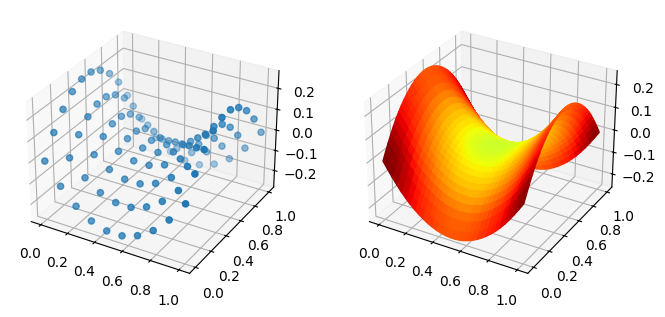

In [57]:
fig, axs = plt.subplots(
    1,2,
    figsize=(4*2, 4), 
    subplot_kw = {"projection":"3d"}
)
axs[0].scatter(
    pred_points[:,0],
    pred_points[:,1],
    pred_points[:,2],
)
plot_surface(surf, ax=axs[1])
plt.show()